<a href="https://colab.research.google.com/github/AhmadKevin000/PCVK_Ganjil2026/blob/main/Week5_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Ahmad Kevin Malik Zakaria'
NIM = '244107020125'
N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Ahmad Kevin Malik Zakaria
NIM : 244107020125 | N = 125
bins   : 16
clip   : 1.0
tile   : 3
L      : 8
WAKTU : 2026-10-02 20:21:14 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 5cea20cf7b3c0eb0


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Week 5 — Histogram, Histogram Equalization, dan Dithering
**Nama:** Ahmad Kevin Malik Zakaria · **NIM:** 244107020125 · **Absen:** 5

**Catatan data:** label kondisi mengikuti penamaan modul (a: gelap, b: lampu, c: flash, d: matahari), bukan pengukuran kondisi kamera. Berkas a ternyata tampak terang, b berbintik, c dan d memiliki pantulan. Analisis menggunakan data yang benar-benar tersedia; citra tidak digelapkan secara buatan.

## E-1 langkah 1–2 — Google Drive, pustaka, dan pembacaan citra


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
KTM1a.jpg : (863, 1347, 3) -> (819, 1286, 3) | crop = (0.025, 0.025, 0.98, 0.975)
KTM1b.jpg : (1023, 1600, 3) -> (956, 1496, 3) | crop = (0.035, 0.03, 0.97, 0.965)
KTM1c.jpg : (830, 1333, 3) -> (697, 1226, 3) | crop = (0.05, 0.085, 0.97, 0.925)
KTM1d.jpg : (1020, 1600, 3) -> (943, 1520, 3) | crop = (0.03, 0.035, 0.98, 0.96)
CONTOH: /content/drive/MyDrive/Matkul Sem 5/PCVK/Images 
BASE: /content/drive/MyDrive/Matkul Sem 5/PCVK


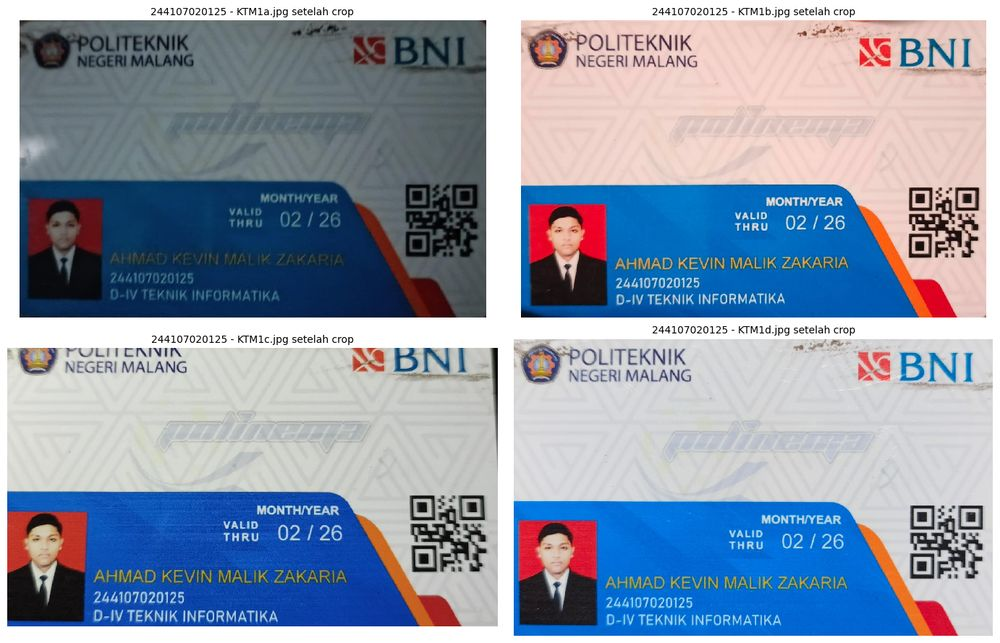

In [3]:
from pathlib import Path
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    from google.colab import drive
except ImportError:
    DI_COLAB = False
else:
    DI_COLAB = True
    drive.mount('/content/drive')

ROOT = Path('/content/drive/MyDrive') if DI_COLAB else Path.cwd()
PCVK = ROOT / 'Matkul Sem 5' / 'PCVK' if DI_COLAB else ROOT
CONTOH = PCVK / 'Images'
BASE = PCVK
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 10})

def baca(folder, nama):
    cocok = [p for p in folder.iterdir() if p.name.lower() == nama.lower()]
    if len(cocok) != 1:
        raise FileNotFoundError(f'Harus ada tepat satu {nama} di {folder}')
    img = cv.imread(str(cocok[0]))
    if img is None:
        raise ValueError(f'Citra gagal dibaca: {cocok[0]}')
    return img

def crop_rel(img, kotak):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = kotak
    return img[round(y1*h):round(y2*h), round(x1*w):round(x2*w)].copy()

CROP = {
    'KTM1a.jpg': (0.025, 0.025, 0.98, 0.975),
    'KTM1b.jpg': (0.035, 0.03, 0.97, 0.965),
    'KTM1c.jpg': (0.05, 0.085, 0.97, 0.925),
    'KTM1d.jpg': (0.03, 0.035, 0.98, 0.96),
}
BERKAS_KTM = {
    'KTM1a.jpg': 'ktm-ruanggelap.jpeg',
    'KTM1b.jpg': 'ktm-dalamruang.jpeg',
    'KTM1c.jpg': 'ktm-senter.jpeg',
    'KTM1d.jpg': 'ktm-matahari.jpeg',
}
lena = baca(CONTOH, 'lena.jpg')
lena_lc = baca(CONTOH, 'lena_lc.jpg')
ktm = {}
for nama, kotak in CROP.items():
    awal = baca(BASE, BERKAS_KTM[nama])
    ktm[nama] = crop_rel(awal, kotak)
    print(nama, ':', awal.shape, '->', ktm[nama].shape, '| crop =', kotak)
gray_ktm = {nama: cv.cvtColor(img, cv.COLOR_BGR2GRAY) for nama, img in ktm.items()}
print('CONTOH:', CONTOH, '\nBASE:', BASE)

def gambar(ax, img, judul):
    if img.ndim == 2:
        ax.imshow(img, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB), interpolation='nearest')
    ax.set_title(NIM + ' - ' + judul)
    ax.axis('off')

def deret(citra, judul, lebar=5):
    fig, axes = plt.subplots(1, len(citra), figsize=(lebar*len(citra), 4), squeeze=False)
    for ax, img, t in zip(axes[0], citra, judul):
        gambar(ax, img, t)
    plt.tight_layout()
    plt.show()

def tabel(kolom, baris):
    teks = '| ' + ' | '.join(kolom) + ' |\n'
    teks += '| ' + ' | '.join(['---']*len(kolom)) + ' |\n'
    teks += '\n'.join('| ' + ' | '.join(map(str, row)) + ' |' for row in baris)
    display(Markdown(teks))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (nama, img) in zip(axes.flat, ktm.items()):
    gambar(ax, img, nama + ' setelah crop')
plt.tight_layout()
plt.show()

## E-1 langkah 3 dan pertanyaan 1 — Histogram manual, NumPy, dan OpenCV


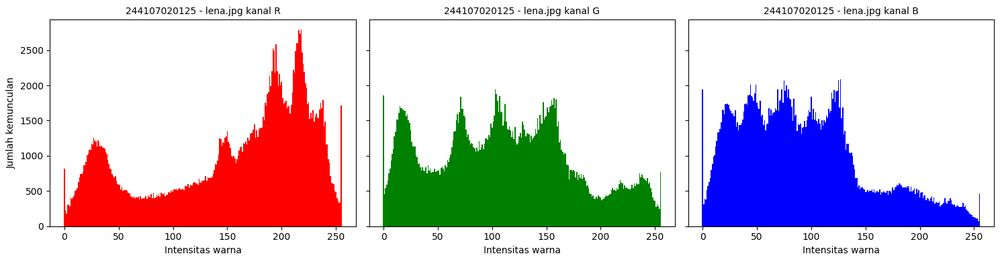

| Citra | Kanal | Manual–NumPy | Manual–OpenCV | NumPy–OpenCV | Jumlah piksel |
| --- | --- | --- | --- | --- | --- |
| lena.jpg | R | 0 | 0 | 0 | 262144 |
| lena.jpg | G | 0 | 0 | 0 | 262144 |
| lena.jpg | B | 0 | 0 | 0 | 262144 |
| lena.jpg | Grayscale | 0 | 0 | 0 | 262144 |

In [4]:
def histogram_manual(img):
    h = np.zeros(256, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    assert h.sum() == img.size
    return h

def percobaan_histogram(bgr, nama):
    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
    baris = []
    kanal = [(t, rgb[:, :, i]) for i, t in enumerate(['R', 'G', 'B'])]
    kanal.append(('Grayscale', cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)))
    for i, (t, img) in enumerate(kanal):
        manual = histogram_manual(img)
        numpy_h, _ = np.histogram(img, bins=256, range=(0, 256))
        cv_h = cv.calcHist([img], [0], None, [256], [0, 256]).ravel().astype(np.int64)
        selisih = [int(np.max(np.abs(a-b))) for a, b in
                   [(manual, numpy_h), (manual, cv_h), (numpy_h, cv_h)]]
        assert selisih == [0, 0, 0]
        baris.append([nama, t, *selisih, int(manual.sum())])
        if i < 3:
            axes[i].bar(np.arange(256), manual, width=1, color=['red', 'green', 'blue'][i])
            axes[i].set_title(f'{NIM} - {nama} kanal {t}')
            axes[i].set_xlabel('Intensitas warna')
    axes[0].set_ylabel('Jumlah kemunculan')
    plt.tight_layout()
    plt.show()
    tabel(['Citra', 'Kanal', 'Manual–NumPy', 'Manual–OpenCV', 'NumPy–OpenCV', 'Jumlah piksel'], baris)

# Tahap 1: contoh
percobaan_histogram(lena, 'lena.jpg')

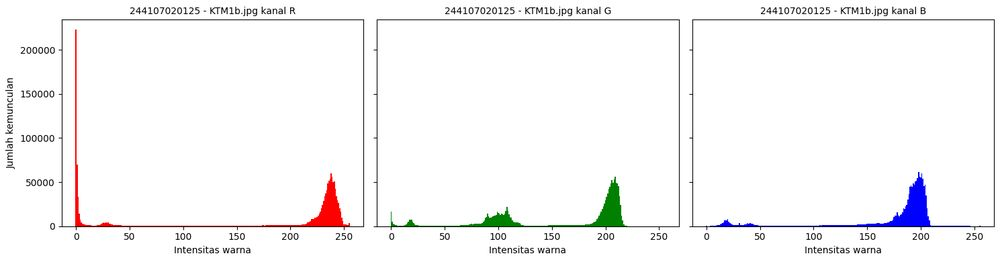

| Citra | Kanal | Manual–NumPy | Manual–OpenCV | NumPy–OpenCV | Jumlah piksel |
| --- | --- | --- | --- | --- | --- |
| KTM1b.jpg | R | 0 | 0 | 0 | 1430176 |
| KTM1b.jpg | G | 0 | 0 | 0 | 1430176 |
| KTM1b.jpg | B | 0 | 0 | 0 | 1430176 |
| KTM1b.jpg | Grayscale | 0 | 0 | 0 | 1430176 |

**Jawaban E1-1:** seluruh selisih maksimum harus dan telah diperiksa sama dengan **0**. Ketiga metode menghitung frekuensi piksel yang sama; perbedaannya hanya cara implementasi.

In [5]:
# Tahap 2: KTM pribadi
percobaan_histogram(ktm['KTM1b.jpg'], 'KTM1b.jpg')
display(Markdown('**Jawaban E1-1:** seluruh selisih maksimum harus dan telah diperiksa sama dengan **0**. Ketiga metode menghitung frekuensi piksel yang sama; perbedaannya hanya cara implementasi.'))

### Pertanyaan E1-2 — Histogram ternormalisasi dan CDF dalam figure 2 × 2


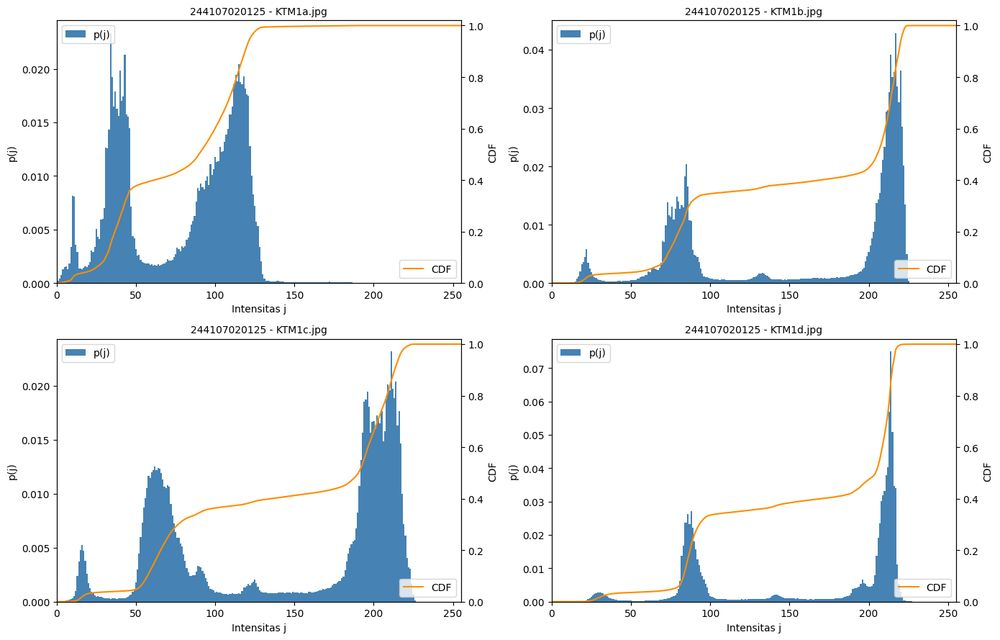

| Citra | Kondisi menurut modul | Rerata | CDF(127) | Median intensitas |
| --- | --- | --- | --- | --- |
| KTM1a.jpg | ruangan gelap (label modul) | 77.56 | 0.9875 | 90 |
| KTM1b.jpg | lampu ruangan | 159.81 | 0.3636 | 206 |
| KTM1c.jpg | flash | 147.41 | 0.3927 | 191 |
| KTM1d.jpg | cahaya matahari | 161.65 | 0.3565 | 205 |

**Jawaban E1-2:** berdasarkan rerata, yang paling gelap adalah **KTM1a.jpg** (77.56) dan paling terang **KTM1d.jpg** (161.65). CDF(127) masing-masing **0.9875** dan **0.3565**; angka ini menyatakan proporsi piksel pada separuh rentang gelap. CDF yang naik lebih awal menunjukkan lebih banyak piksel berintensitas rendah, sedangkan lonjakan dekat 255 menunjukkan penumpukan area terang. Foto lampu ruangan berbintik, sementara pantulan pada foto flash/matahari menambah piksel sangat terang. Berkas a tidak tampak sebagai foto gelap yang ekstrem. Auto-exposure, pantulan kartu, dan pemrosesan kamera dapat membuat urutan kecerahan berbeda dari urutan kondisi pencahayaan; histogram saja tidak membuktikan kondisi akuisisinya.

In [6]:
kondisi = {'KTM1a.jpg': 'ruangan gelap (label modul)', 'KTM1b.jpg': 'lampu ruangan',
           'KTM1c.jpg': 'flash', 'KTM1d.jpg': 'cahaya matahari'}
statistik = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (nama, gray) in zip(axes.flat, gray_ktm.items()):
    h, _ = np.histogram(gray, 256, (0, 256))
    p = h / gray.size
    cdf = np.cumsum(p)
    assert h.sum() == gray.size and np.isclose(p.sum(), 1) and np.isclose(cdf[-1], 1)
    ax.bar(np.arange(256), p, width=1, color='steelblue', label='p(j)')
    ax.set(xlim=(0, 255), xlabel='Intensitas j', ylabel='p(j)', title=f'{NIM} - {nama}')
    kanan = ax.twinx()
    kanan.plot(cdf, color='darkorange', label='CDF')
    kanan.set(ylim=(0, 1.02), ylabel='CDF')
    ax.legend(loc='upper left'); kanan.legend(loc='lower right')
    statistik[nama] = (float(gray.mean()), float(cdf[127]), int(np.searchsorted(cdf, 0.5)))
plt.tight_layout()
plt.show()
tabel(['Citra', 'Kondisi menurut modul', 'Rerata', 'CDF(127)', 'Median intensitas'],
      [[n, kondisi[n], f'{v[0]:.2f}', f'{v[1]:.4f}', v[2]] for n, v in statistik.items()])
gelap = min(statistik, key=lambda n: statistik[n][0])
terang = max(statistik, key=lambda n: statistik[n][0])
display(Markdown(f'**Jawaban E1-2:** berdasarkan rerata, yang paling gelap adalah **{gelap}** '
    f'({statistik[gelap][0]:.2f}) dan paling terang **{terang}** ({statistik[terang][0]:.2f}). '
    f'CDF(127) masing-masing **{statistik[gelap][1]:.4f}** dan **{statistik[terang][1]:.4f}**; '
    'angka ini menyatakan proporsi piksel pada separuh rentang gelap. '
    'CDF yang naik lebih awal menunjukkan lebih banyak piksel berintensitas rendah, sedangkan lonjakan dekat 255 menunjukkan penumpukan area terang. '
    'Foto lampu ruangan berbintik, sementara pantulan pada foto flash/matahari menambah piksel sangat terang. '
    'Berkas a tidak tampak sebagai foto gelap yang ekstrem. Auto-exposure, pantulan kartu, dan pemrosesan kamera dapat membuat urutan kecerahan berbeda dari urutan kondisi pencahayaan; histogram saja tidak membuktikan kondisi akuisisinya.'))

### Pertanyaan E1-3 — Histogram KTM1b dengan bin pribadi dan 256 bin

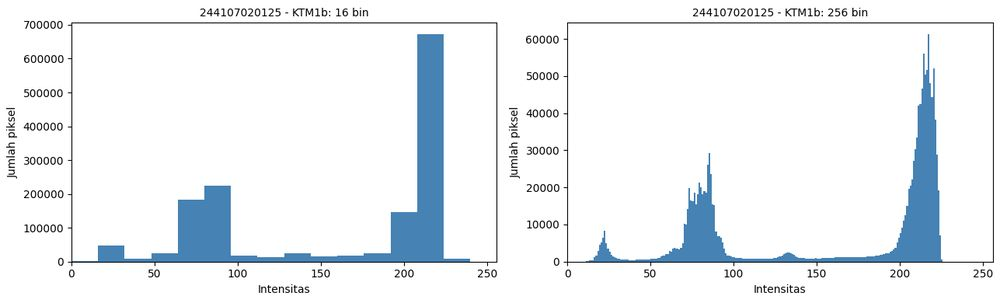

**Jawaban E1-3:** 16 bin menggabungkan **16 intensitas** dalam setiap batang. Puncak sempit, celah, dan perbedaan frekuensi antarintensitas di dalam satu bin hilang. Bentuk gelap–terang secara umum masih terlihat, tetapi frekuensi setiap intensitas tidak dapat direkonstruksi dari histogram yang telah digabung. Jumlah piksel tetap sama.

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, bins in zip(axes, [PARAM['bins'], 256]):
    h, tepi = np.histogram(gray_ktm['KTM1b.jpg'], bins=bins, range=(0, 256))
    ax.bar(tepi[:-1], h, width=np.diff(tepi), align='edge', color='steelblue')
    ax.set(title=f'{NIM} - KTM1b: {bins} bin', xlabel='Intensitas', ylabel='Jumlah piksel', xlim=(0, 256))
    assert h.sum() == gray_ktm['KTM1b.jpg'].size
plt.tight_layout()
plt.show()
display(Markdown(f'**Jawaban E1-3:** {PARAM["bins"]} bin menggabungkan **{256//PARAM["bins"]} intensitas** dalam setiap batang. Puncak sempit, celah, dan perbedaan frekuensi antarintensitas di dalam satu bin hilang. Bentuk gelap–terang secara umum masih terlihat, tetapi frekuensi setiap intensitas tidak dapat direkonstruksi dari histogram yang telah digabung. Jumlah piksel tetap sama.'))

## E-2 langkah 1–2 — Histogram equalization manual dan cv.equalizeHist


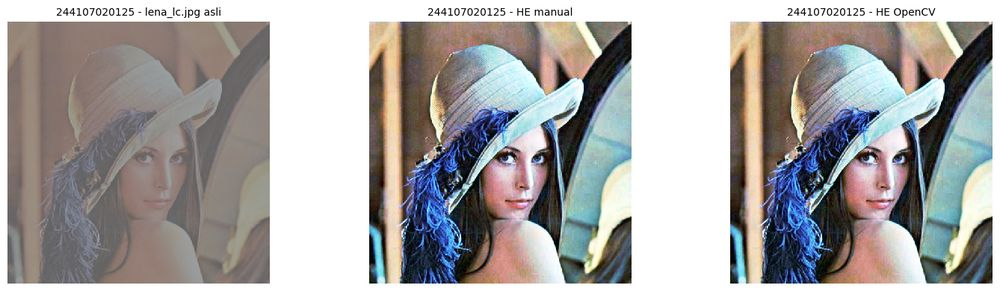

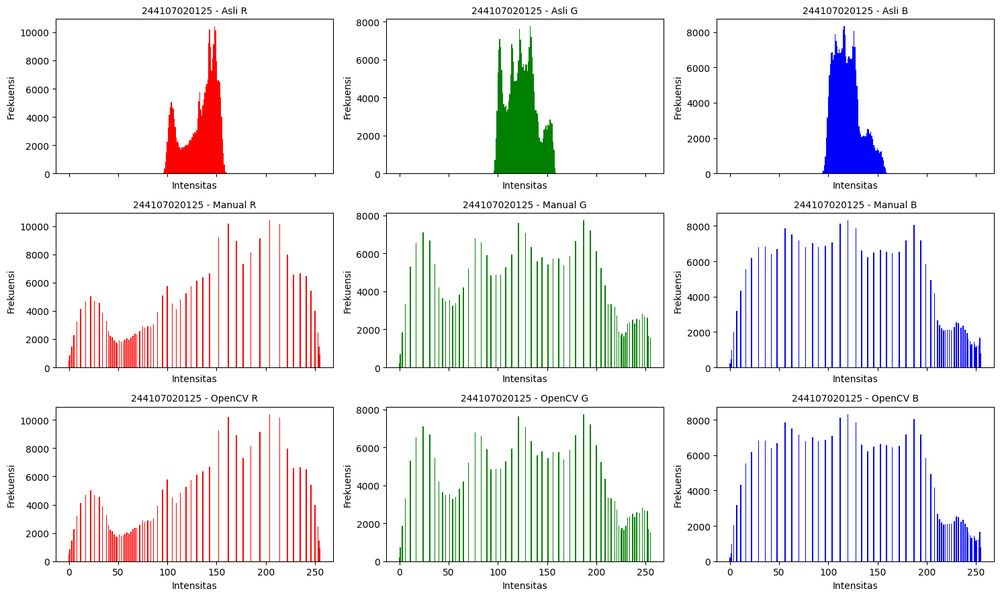

| Citra | Kanal | Selisih maksimum manual–OpenCV |
| --- | --- | --- |
| lena_lc.jpg | B | 0 |
| lena_lc.jpg | G | 0 |
| lena_lc.jpg | R | 0 |

In [8]:
def equalization_manual(gray):
    h = histogram_manual(gray)
    cdf = np.cumsum(h) / gray.size
    lut = np.round(255 * cdf).astype(np.uint8)
    return lut[gray]

def selisih_maks(a, b):
    return int(np.abs(a.astype(np.int16) - b.astype(np.int16)).max())

def he_warna(bgr, fungsi):
    return cv.merge([fungsi(c) for c in cv.split(bgr)])

def percobaan_he(bgr, nama):
    manual = he_warna(bgr, equalization_manual)
    opencv = he_warna(bgr, cv.equalizeHist)
    deret([bgr, manual, opencv], [nama + ' asli', 'HE manual', 'HE OpenCV'])
    fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
    for row, (img, metode) in enumerate([(bgr, 'Asli'), (manual, 'Manual'), (opencv, 'OpenCV')]):
        for col, (kanal, label, warna) in enumerate([(2, 'R', 'red'), (1, 'G', 'green'), (0, 'B', 'blue')]):
            h, _ = np.histogram(img[:, :, kanal], 256, (0, 256))
            axes[row, col].bar(np.arange(256), h, width=1, color=warna)
            axes[row, col].set(title=f'{NIM} - {metode} {label}', xlabel='Intensitas', ylabel='Frekuensi')
    plt.tight_layout()
    plt.show()
    tabel(['Citra', 'Kanal', 'Selisih maksimum manual–OpenCV'],
          [[nama, t, selisih_maks(manual[:, :, i], opencv[:, :, i])] for i, t in enumerate(['B', 'G', 'R'])])
    return manual, opencv

# Tahap 1: contoh kontras rendah
he_lena_manual, he_lena_cv = percobaan_he(lena_lc, 'lena_lc.jpg')

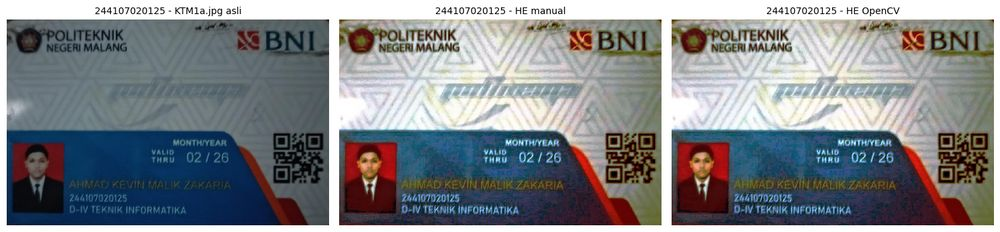

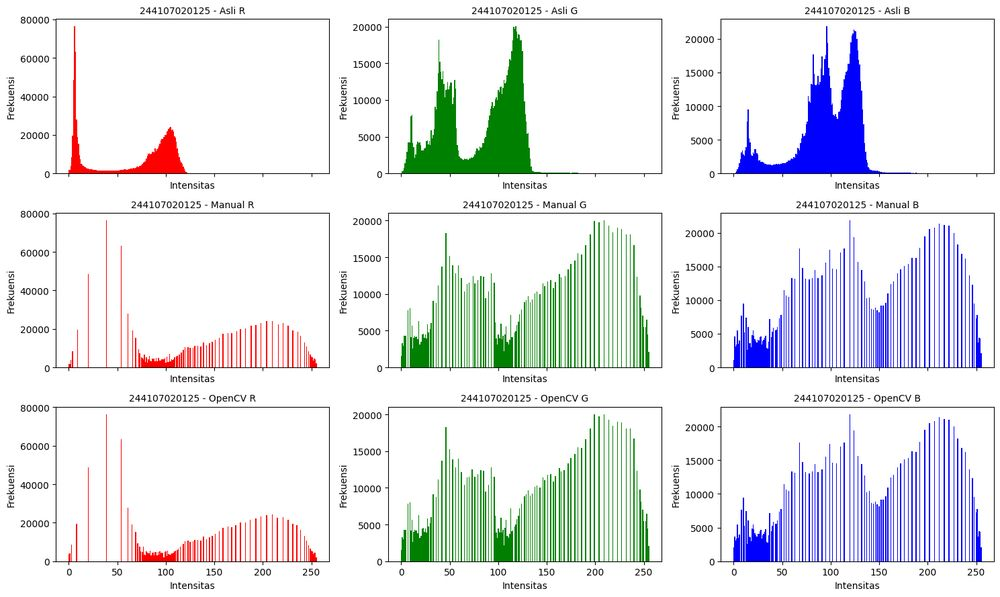

| Citra | Kanal | Selisih maksimum manual–OpenCV |
| --- | --- | --- |
| KTM1a.jpg | B | 1 |
| KTM1a.jpg | G | 1 |
| KTM1a.jpg | R | 1 |

**Jawaban langkah 2:** selisih yang tidak nol terutama disebabkan rumus modul memakai `255 × CDF`, sedangkan OpenCV memakai `255 × (CDF − CDF_min)/(1 − CDF_min)`. Pembulatan juga dapat menyebabkan selisih kecil. Nilai minimum yang muncul pada citra dipetakan OpenCV ke 0; pada rumus modul nilainya dapat lebih besar dari 0. Histogram hasil tidak harus rata sempurna karena intensitasnya diskret.

In [9]:
# Tahap 2: KTM1a sesuai instruksi modul
he_ktm_manual, he_ktm_cv = percobaan_he(ktm['KTM1a.jpg'], 'KTM1a.jpg')
display(Markdown('**Jawaban langkah 2:** selisih yang tidak nol terutama disebabkan rumus modul memakai `255 × CDF`, sedangkan OpenCV memakai `255 × (CDF − CDF_min)/(1 − CDF_min)`. Pembulatan juga dapat menyebabkan selisih kecil. Nilai minimum yang muncul pada citra dipetakan OpenCV ke 0; pada rumus modul nilainya dapat lebih besar dari 0. Histogram hasil tidak harus rata sempurna karena intensitasnya diskret.'))

## E-2 langkah 3–4 — Ekualisasi BGR, Y, V, dan L


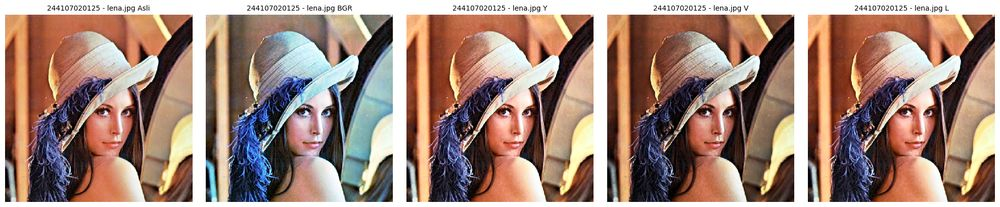

| Cara | Pergeseran Hue (derajat) | Rerata kecerahan |
| --- | --- | --- |
| Asli | 0.0000 | 122.24 |
| BGR | 53.0257 | 127.37 |
| Y | 0.4047 | 127.90 |
| V | 0.8728 | 100.55 |
| L | 1.6529 | 122.72 |

In [10]:
def kanal_terang(bgr, ruang, fungsi):
    konversi = {
        'Y': (cv.COLOR_BGR2YCrCb, cv.COLOR_YCrCb2BGR, 0),
        'V': (cv.COLOR_BGR2HSV, cv.COLOR_HSV2BGR, 2),
        'L': (cv.COLOR_BGR2LAB, cv.COLOR_LAB2BGR, 0),
    }
    maju, balik, indeks = konversi[ruang]
    img = cv.cvtColor(bgr, maju)
    img[:, :, indeks] = fungsi(img[:, :, indeks])
    return cv.cvtColor(img, balik)

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    return float(np.minimum(d, 180-d).mean()) * 2

def variasi_warna(bgr, nama):
    hasil = {'Asli': bgr, 'BGR': he_warna(bgr, cv.equalizeHist)}
    hasil.update({k: kanal_terang(bgr, k, cv.equalizeHist) for k in ['Y', 'V', 'L']})
    deret(list(hasil.values()), [nama + ' ' + k for k in hasil], lebar=4)
    tabel(['Cara', 'Pergeseran Hue (derajat)', 'Rerata kecerahan'],
          [[k, f'{geser_hue(bgr, v):.4f}', f'{cv.cvtColor(v, cv.COLOR_BGR2GRAY).mean():.2f}'] for k, v in hasil.items()])
    return hasil

warna_lena = variasi_warna(lena, 'lena.jpg')

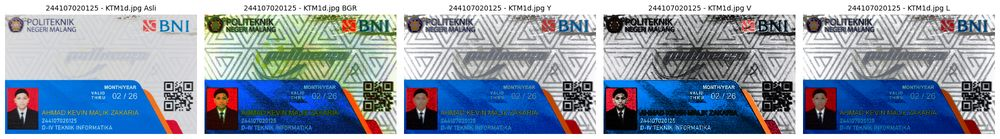

| Cara | Pergeseran Hue (derajat) | Rerata kecerahan |
| --- | --- | --- |
| Asli | 0.0000 | 161.65 |
| BGR | 62.1256 | 125.15 |
| Y | 2.0418 | 134.09 |
| V | 4.1456 | 105.51 |
| L | 9.3850 | 124.98 |

**Jawaban warna 1:** pergeseran Hue terbesar adalah **BGR**, sebesar **62.1256°**.

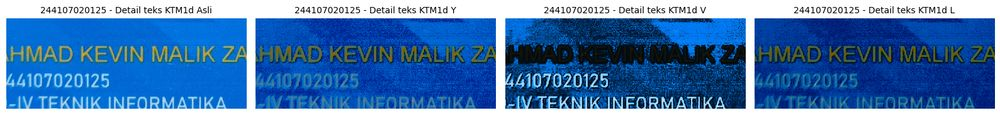

In [11]:
warna_ktm = variasi_warna(ktm['KTM1d.jpg'], 'KTM1d.jpg')
asli_d = ktm['KTM1d.jpg']
terbesar = max(['BGR', 'Y', 'V', 'L'], key=lambda k: geser_hue(asli_d, warna_ktm[k]))
display(Markdown(f'**Jawaban warna 1:** pergeseran Hue terbesar adalah **{terbesar}**, sebesar **{geser_hue(asli_d, warna_ktm[terbesar]):.4f}°**.'))
ROI_D = (0.21, 0.73, 0.59, 0.96)
deret([crop_rel(warna_ktm[k], ROI_D) for k in ['Asli', 'Y', 'V', 'L']],
      ['Detail teks KTM1d ' + k for k in ['Asli', 'Y', 'V', 'L']], lebar=4)

### Jawaban warna 2–3 dan catatan pengamatan
- **Mengapa Hue tidak nol?** Konversi ruang warna dilakukan pada uint8. Pembulatan dan clipping BGR mengubah perbandingan kanal; beberapa warna hasil berada di luar rentang yang dapat direpresentasikan. Pada HSV, V yang menjadi 0 menghasilkan hitam sehingga Hue tidak lagi bermakna. Hue pada piksel hampir abu-abu juga sensitif terhadap selisih kanal yang kecil.
- **Pemilihan kanal:** di antara Y, V, dan L, kanal **Y** paling sesuai pada KTM1d ini. Pergeseran Hue-nya **3.2695°**, lebih kecil daripada V (**4.1103°**) dan L (**8.7272°**); rerata kecerahannya **142.76**. Pada crop blok teks bawah, Y mempertahankan permukaan biru lebih halus dibanding V yang menjadi sangat gelap dan berbintik. Nama masih dapat dikenali di luar pantulan. Pantulan putih tetap menutupi sebagian huruf pada semua metode, sehingga tidak boleh dianggap pulih. Ini pilihan relatif antarhasil ekualisasi, bukan klaim bahwa hasil lebih mudah dibaca daripada asli pada semua bagian.

| Cara | Catatan pengamatan visual yang diperiksa |
|---|---|
| Asli | Blok biru terang; pantulan putih memotong nama dan NIM. |
| BGR | Keseimbangan warna berubah karena tiap kanal mendapat pemetaan berbeda. |
| Y | Perbedaan terang–gelap lebih tegas, sebagian warna jenuh dapat terpotong. |
| V | Area biru jauh lebih gelap, bintik kontras menonjol, dan nama menjadi lebih sulit dibaca. |
| L | Kontras kecerahan berubah, tetapi hasil konversi dapat menggeser biru dan warna huruf. |

### Jawaban warna 4 — CLAHE pada kanal V dengan parameter NIM

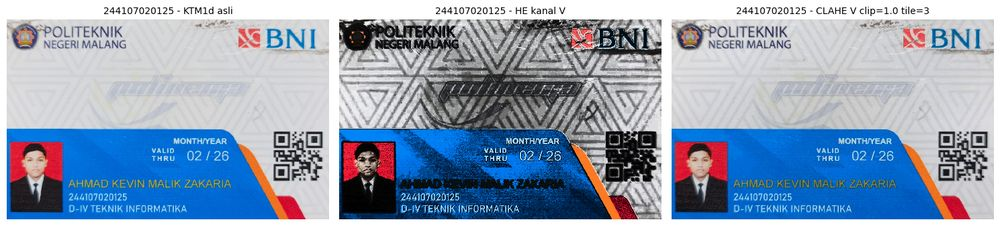

| Metode | Hue (derajat) | Rerata kecerahan |
| --- | --- | --- |
| Asli | 0.0000 | 161.65 |
| HE V | 4.1456 | 105.51 |
| CLAHE V | 0.9712 | 155.16 |

CLAHE V dibanding HE V: perubahan pergeseran Hue **-3.1744°**, perubahan rerata kecerahan **+49.65**. CLAHE memakai histogram lokal dengan pembatasan penguatan kontras. Pantulan yang telah jenuh tetap tidak mengandung detail huruf yang dapat dipulihkan.

In [12]:
def clahe_gray(gray, clip=None):
    clip = PARAM['clip'] if clip is None else float(clip)
    return cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile'])).apply(gray)

clahe_v = kanal_terang(asli_d, 'V', clahe_gray)
deret([asli_d, warna_ktm['V'], clahe_v], ['KTM1d asli', 'HE kanal V', f'CLAHE V clip={PARAM["clip"]} tile={PARAM["tile"]}'])
tabel(['Metode', 'Hue (derajat)', 'Rerata kecerahan'],
      [[k, f'{geser_hue(asli_d, v):.4f}', f'{cv.cvtColor(v, cv.COLOR_BGR2GRAY).mean():.2f}']
       for k, v in [('Asli', asli_d), ('HE V', warna_ktm['V']), ('CLAHE V', clahe_v)]])
delta_h = geser_hue(asli_d, clahe_v) - geser_hue(asli_d, warna_ktm['V'])
delta_mean = cv.cvtColor(clahe_v, cv.COLOR_BGR2GRAY).mean() - cv.cvtColor(warna_ktm['V'], cv.COLOR_BGR2GRAY).mean()
display(Markdown(f'CLAHE V dibanding HE V: perubahan pergeseran Hue **{delta_h:+.4f}°**, perubahan rerata kecerahan **{delta_mean:+.2f}**. CLAHE memakai histogram lokal dengan pembatasan penguatan kontras. Pantulan yang telah jenuh tetap tidak mengandung detail huruf yang dapat dipulihkan.'))

## Pertanyaan E2-1 — Ekualisasi global grayscale dan PSNR


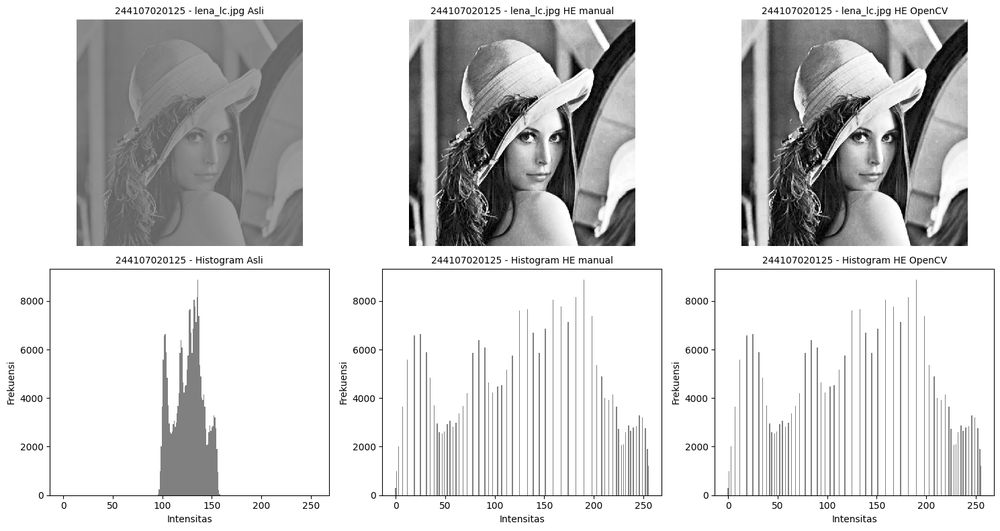

| Citra | Selisih maksimum manual–OpenCV | PSNR asli–manual (dB) | PSNR asli–OpenCV (dB) |
| --- | --- | --- | --- |
| lena_lc.jpg | 0 | 12.7232 | 12.7232 |

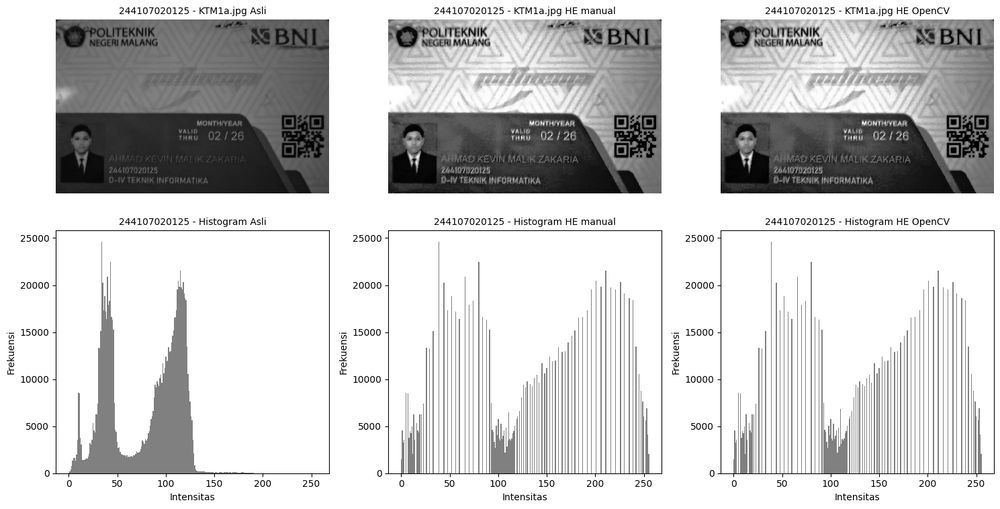

| Citra | Selisih maksimum manual–OpenCV | PSNR asli–manual (dB) | PSNR asli–OpenCV (dB) |
| --- | --- | --- | --- |
| KTM1a.jpg | 1 | 11.9521 | 11.9523 |

**Jawaban E2-1c:** PSNR citra terhadap dirinya sendiri adalah tak hingga. Ekualisasi mengubah intensitas sehingga MSE terhadap asli menjadi positif dan PSNR turun menjadi angka pada tabel. Perubahan tersebut bisa memperjelas kontras, jadi PSNR yang lebih rendah tidak otomatis berarti keterbacaan memburuk. PSNR mengukur kesamaan piksel terhadap referensi, bukan kemampuan membaca teks; ia tidak layak menjadi satu-satunya ukuran keterbacaan.

In [13]:
def psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64)-hasil.astype(np.float64))**2)
    return float('inf') if mse == 0 else float(10*np.log10(255**2/mse))

def he_gray_layout(gray, nama):
    manual = equalization_manual(gray)
    hasil_cv = cv.equalizeHist(gray)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for i, (img, t) in enumerate([(gray, 'Asli'), (manual, 'HE manual'), (hasil_cv, 'HE OpenCV')]):
        gambar(axes[0, i], img, nama + ' ' + t)
        h, _ = np.histogram(img, 256, (0, 256))
        axes[1, i].bar(np.arange(256), h, width=1, color='gray')
        axes[1, i].set(title=NIM+' - Histogram '+t, xlabel='Intensitas', ylabel='Frekuensi')
    plt.tight_layout()
    plt.show()
    tabel(['Citra', 'Selisih maksimum manual–OpenCV', 'PSNR asli–manual (dB)', 'PSNR asli–OpenCV (dB)'],
          [[nama, selisih_maks(manual, hasil_cv), f'{psnr(gray, manual):.4f}', f'{psnr(gray, hasil_cv):.4f}']])
    return manual, hasil_cv

_ = he_gray_layout(cv.cvtColor(lena_lc, cv.COLOR_BGR2GRAY), 'lena_lc.jpg')
abu_a = gray_ktm['KTM1a.jpg']
manual_a, global_a = he_gray_layout(abu_a, 'KTM1a.jpg')
display(Markdown('**Jawaban E2-1c:** PSNR citra terhadap dirinya sendiri adalah tak hingga. Ekualisasi mengubah intensitas sehingga MSE terhadap asli menjadi positif dan PSNR turun menjadi angka pada tabel. Perubahan tersebut bisa memperjelas kontras, jadi PSNR yang lebih rendah tidak otomatis berarti keterbacaan memburuk. PSNR mengukur kesamaan piksel terhadap referensi, bukan kemampuan membaca teks; ia tidak layak menjadi satu-satunya ukuran keterbacaan.'))

## Pertanyaan E2-2 — CLAHE global versus lokal dan variasi clipLimit


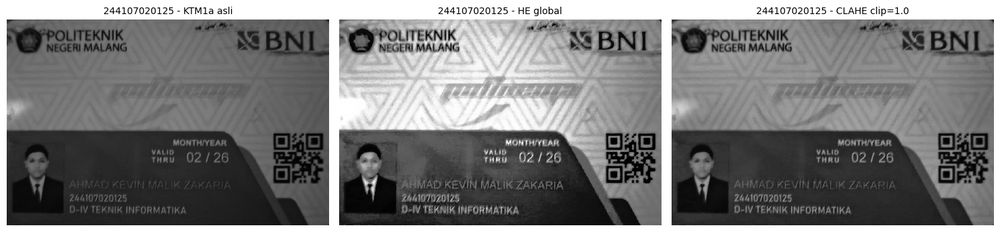

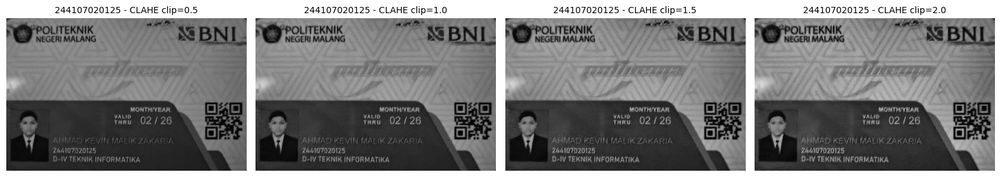

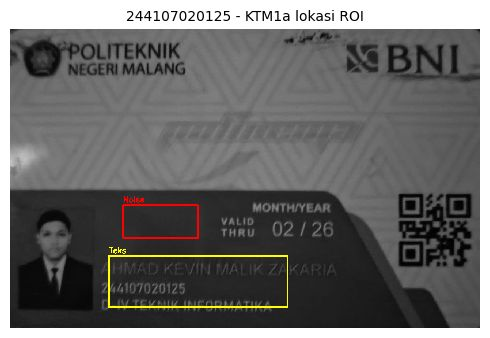

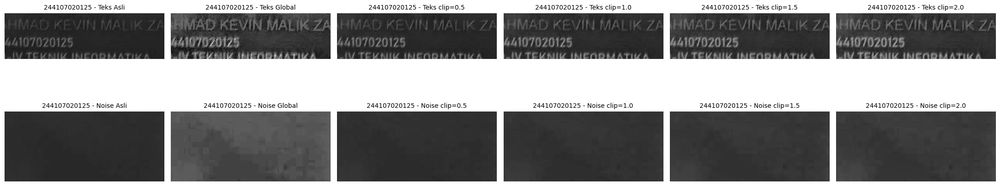

| Metode | Rerata citra | SD ROI biru |
| --- | --- | --- |
| Asli | 77.56 | 2.04 |
| Global | 129.10 | 8.48 |
| clip=0.5 | 89.94 | 2.43 |
| clip=1.0 | 95.96 | 3.03 |
| clip=1.5 | 99.36 | 3.69 |
| clip=2.0 | 101.98 | 4.33 |

SD ROI hanya indikator variasi lokal; termasuk tekstur/gradien, bukan estimasi noise murni.


In [14]:
lokal_a = clahe_gray(abu_a)
deret([abu_a, global_a, lokal_a], ['KTM1a asli', 'HE global', f'CLAHE clip={PARAM["clip"]}'])
clips = [PARAM['clip']-0.5, PARAM['clip'], PARAM['clip']+0.5, PARAM['clip']+1.0]
hasil_clips = {c: clahe_gray(abu_a, c) for c in clips}
deret(list(hasil_clips.values()), [f'CLAHE clip={c}' for c in clips], lebar=4)
ROI_TEKS = (0.21, 0.76, 0.59, 0.93)
ROI_NOISE = (0.24, 0.59, 0.40, 0.70)
penanda = cv.cvtColor(abu_a, cv.COLOR_GRAY2BGR)
for label, kotak, warna in [('Teks', ROI_TEKS, (0, 255, 255)), ('Noise', ROI_NOISE, (0, 0, 255))]:
    h, w = abu_a.shape
    x1, y1, x2, y2 = [round(v*s) for v, s in zip(kotak, [w, h, w, h])]
    cv.rectangle(penanda, (x1, y1), (x2, y2), warna, 3)
    cv.putText(penanda, label, (x1, y1-8), cv.FONT_HERSHEY_SIMPLEX, 0.7, warna, 2)
deret([penanda], ['KTM1a lokasi ROI'])
metode_detail = {'Asli': abu_a, 'Global': global_a, **{f'clip={c}': img for c, img in hasil_clips.items()}}
fig, axes = plt.subplots(2, len(metode_detail), figsize=(22, 6))
for col, (nama, img) in enumerate(metode_detail.items()):
    gambar(axes[0, col], crop_rel(img, ROI_TEKS), 'Teks '+nama)
    gambar(axes[1, col], crop_rel(img, ROI_NOISE), 'Noise '+nama)
plt.tight_layout()
plt.show()
tabel(['Metode', 'Rerata citra', 'SD ROI biru'],
      [[nama, f'{img.mean():.2f}', f'{crop_rel(img, ROI_NOISE).std():.2f}'] for nama, img in metode_detail.items()])
print('SD ROI hanya indikator variasi lokal; termasuk tekstur/gradien, bukan estimasi noise murni.')

### Jawaban E2-2a–b
Membandingkan tepi huruf nama dan angka NIM pada baris crop teks, serta bintik di blok biru pada baris crop noise. Berkas KTM1a yang tersedia sudah cukup terang dan tulisan asli masih terbaca, sehingga peningkatan tidak boleh disimpulkan hanya dari label 'ruangan gelap'.

**CLAHE lebih terbaca daripada HE global** pada crop nama/NIM: huruf tetap terang dan utuh, sedangkan HE global membuat bagian dalam huruf nama gelap dan memperkuat tekstur kotak di latar. Pilihan konservatif untuk citra ini adalah **clipLimit 2.5, tile 2 × 2**: meningkatkan kontras lokal dengan penguatan tekstur lebih ringan daripada 3.0, 3.5, dan 4.0. Parameter pribadi 3.0 tetap ditampilkan sebagai percobaan utama. SD ROI biru berturut-turut **6.82, 7.79, 8.72, 9.74**; bintik dan pola blok makin menonjol pada 3.5–4.0, khususnya bagian kiri-bawah ROI noise. Peningkatan SD mendukung bertambahnya variasi lokal, tetapi tidak membuktikan bahwa semua variasi tersebut noise. Keterbacaan nama/NIM dinilai secara visual dari crop, bukan dari nilai PSNR atau SD terbesar.

## E-3 tugas 1 — Floyd–Steinberg


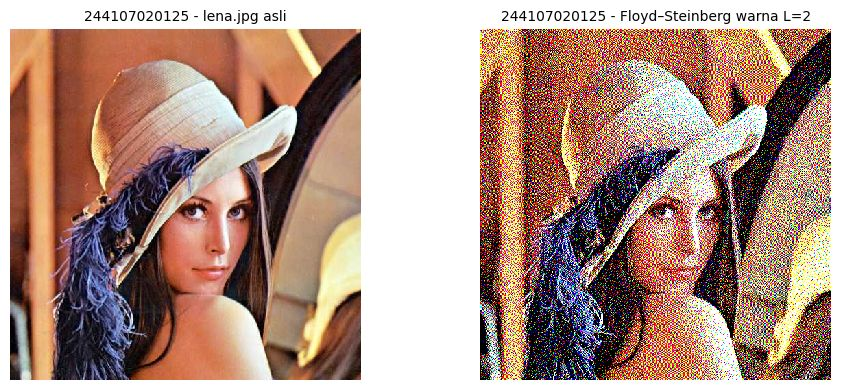

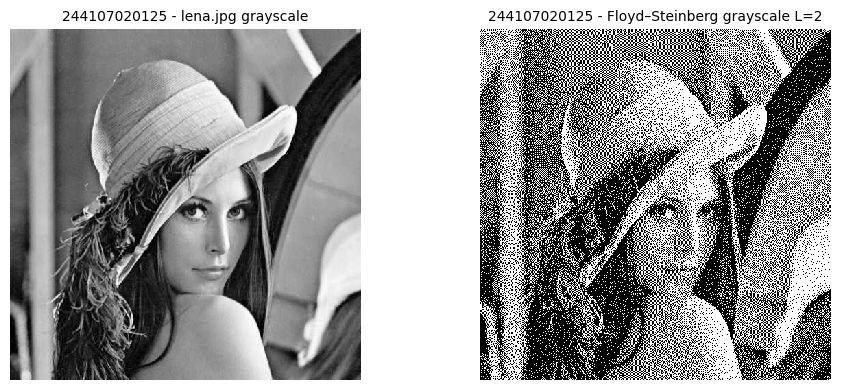

Level per kanal yang diizinkan: [0, 255] | pemeriksaan lulus
Level per kanal yang diizinkan: [0, 255] | pemeriksaan lulus


In [15]:
def floyd_steinberg(gray, L=2):
    if gray.ndim != 2 or L < 2:
        raise ValueError('Masukan harus grayscale dan L >= 2')
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L-1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x+1 < W:
                img[y, x+1] += error * 7 / 16
            if x > 0 and y+1 < H:
                img[y+1, x-1] += error * 3 / 16
            if y+1 < H:
                img[y+1, x] += error * 5 / 16
            if x+1 < W and y+1 < H:
                img[y+1, x+1] += error / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def dither_warna(bgr, L):
    return cv.merge([floyd_steinberg(c, L) for c in cv.split(bgr)])

def periksa_palet(img, L):
    palet = (np.arange(L, dtype=np.float32)*(255.0/(L-1))).astype(np.uint8)
    assert np.isin(img, palet).all()
    print('Level per kanal yang diizinkan:', palet.tolist(), '| pemeriksaan lulus')

dither_lena_warna = dither_warna(lena, 2)
abu_lena = cv.cvtColor(lena, cv.COLOR_BGR2GRAY)
dither_lena_gray = floyd_steinberg(abu_lena, 2)
deret([lena, dither_lena_warna], ['lena.jpg asli', 'Floyd–Steinberg warna L=2'])
deret([abu_lena, dither_lena_gray], ['lena.jpg grayscale', 'Floyd–Steinberg grayscale L=2'])
periksa_palet(dither_lena_warna, 2)
periksa_palet(dither_lena_gray, 2)

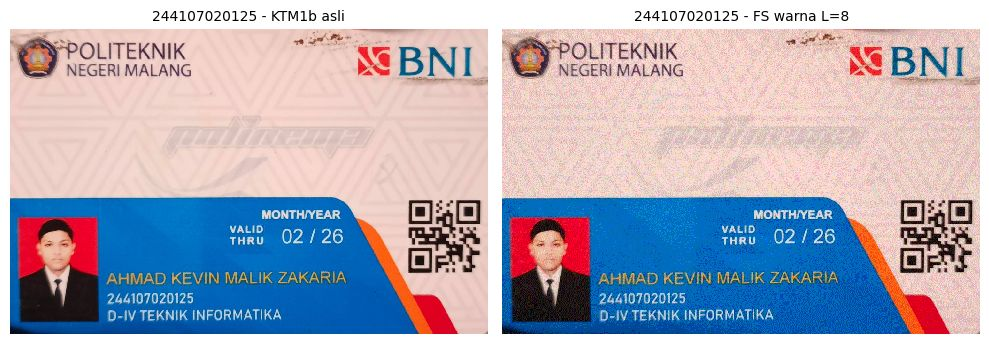

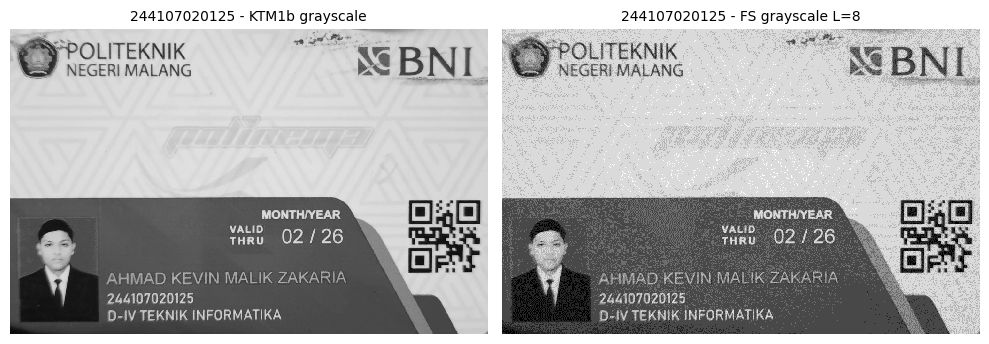

Level per kanal yang diizinkan: [0, 36, 72, 109, 145, 182, 218, 254] | pemeriksaan lulus
Level per kanal yang diizinkan: [0, 36, 72, 109, 145, 182, 218, 254] | pemeriksaan lulus


In [16]:
bgr_b = ktm['KTM1b.jpg']
abu_b = gray_ktm['KTM1b.jpg']
dither_b_warna = dither_warna(bgr_b, PARAM['L'])
dither_b_gray = floyd_steinberg(abu_b, PARAM['L'])
deret([bgr_b, dither_b_warna], ['KTM1b asli', f'FS warna L={PARAM["L"]}'])
deret([abu_b, dither_b_gray], ['KTM1b grayscale', f'FS grayscale L={PARAM["L"]}'])
periksa_palet(dither_b_warna, PARAM['L'])
periksa_palet(dither_b_gray, PARAM['L'])

## E-3 tugas 2 — Grayscale → histogram equalization → dithering


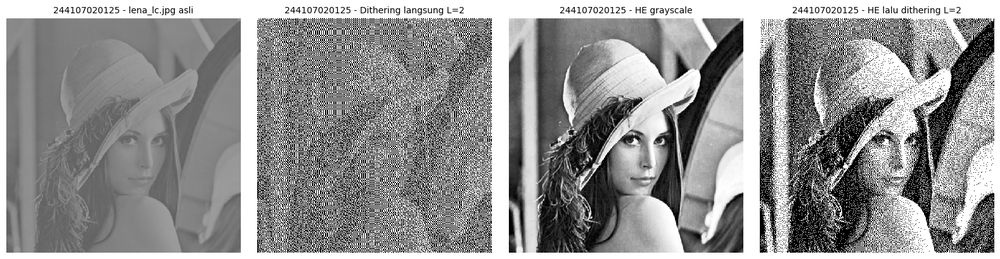

Level per kanal yang diizinkan: [0, 255] | pemeriksaan lulus
Level per kanal yang diizinkan: [0, 255] | pemeriksaan lulus


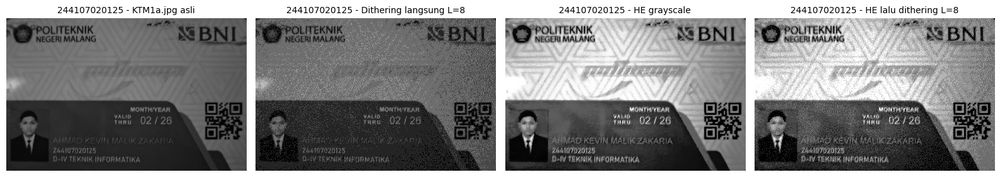

Level per kanal yang diizinkan: [0, 36, 72, 109, 145, 182, 218, 254] | pemeriksaan lulus
Level per kanal yang diizinkan: [0, 36, 72, 109, 145, 182, 218, 254] | pemeriksaan lulus


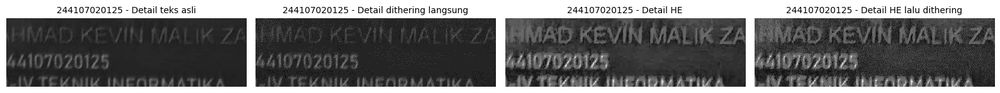

In [18]:
def banding_urutan(gray, nama, L):
    he = cv.equalizeHist(gray)
    langsung = floyd_steinberg(gray, L)
    setelah_he = floyd_steinberg(he, L)
    deret([gray, langsung, he, setelah_he],
          [nama+' asli', f'Dithering langsung L={L}', 'HE grayscale', f'HE lalu dithering L={L}'], lebar=4)
    periksa_palet(langsung, L)
    periksa_palet(setelah_he, L)
    return langsung, he, setelah_he

urutan_lena = banding_urutan(cv.cvtColor(lena_lc, cv.COLOR_BGR2GRAY), 'lena_lc.jpg', 2)

langsung_a, he_a, he_fs_a = banding_urutan(abu_a, 'KTM1a.jpg', PARAM['L'])
deret([crop_rel(img, ROI_TEKS) for img in [abu_a, langsung_a, he_a, he_fs_a]],
      ['Detail teks asli', 'Detail dithering langsung', 'Detail HE', 'Detail HE lalu dithering'], lebar=4)

### Pembahasan E-3
Pada lena_lc, ekualisasi sebelum dithering memperbesar perbedaan intensitas sehingga struktur wajah, topi, dan rambut lebih terpisah. Dithering langsung pada citra kontras rendah menghasilkan pola titik dengan kepadatan yang mirip di banyak area.

Pada KTM1a, dasar perbandingan adalah crop nama dan NIM. **Dithering langsung lebih terbaca**, terutama angka NIM yang lebih putih dan utuh. HE lalu dithering justru membuat banyak bagian huruf gelap/terputus, karena HE global pada citra ini menggelapkan sebagian intensitas huruf dan memperkuat variasi blok biru. Ini berbeda dari contoh lena_lc: berkas KTM1a yang tersedia sudah cukup terang, sehingga ekualisasi tidak otomatis menguntungkan. Citra grayscale asli masih paling nyaman dibaca di antara panel tersebut. Dithering mengurangi level intensitas, bukan menghilangkan noise. Pada KTM1b yang sejak awal berbintik, pola difusi ditambahkan di atas variasi tersebut; hasilnya tidak dapat dianggap sebagai pemulihan detail.

Perbandingan dengan ilustrasi PDF bersifat visual. Persamaan piksel dengan gambar hasil pada PDF tidak dapat dibuktikan karena citra hasil referensi digital tidak disertakan; kompresi dan skala cetak juga berbeda.

In [21]:
assert PARAM == {'bins': 16, 'clip': 1.0, 'tile': 3, 'L': 8}
for img in [manual_a, global_a, lokal_a, langsung_a, he_fs_a]:
    assert img.shape == abu_a.shape and img.dtype == np.uint8
assert set(np.unique(dither_lena_gray)).issubset({0, 255})
palette_param_l = set((np.arange(PARAM['L'], dtype=np.float32)*(255.0/(PARAM['L']-1))).astype(np.uint8))
for img in [dither_b_gray, langsung_a, he_fs_a]:
    assert set(np.unique(img)).issubset(palette_param_l)
print('LULUS: parameter NIM, dimensi, uint8, dan palet L=2.')
print('LULUS: histogram manual/NumPy/OpenCV telah diperiksa pada lena dan KTM1b.')
print('LULUS: normalisasi p(j) dan CDF telah diperiksa pada keempat KTM.')
print('Selesai: E-1, E-2, E-3. Semua hasil tampil langsung pada notebook.')

LULUS: parameter NIM, dimensi, uint8, dan palet L=2.
LULUS: histogram manual/NumPy/OpenCV telah diperiksa pada lena dan KTM1b.
LULUS: normalisasi p(j) dan CDF telah diperiksa pada keempat KTM.
Selesai: E-1, E-2, E-3. Semua hasil tampil langsung pada notebook.
